# 01 — Exploratory Data Analysis (EDA)
### Tugas Mandiri Hari 1 · Python untuk Sistem Cerdas · Project: ProjectMatch AI

| Keterangan | Isi |
|---|---|
| Nama Mahasiswa | Khoirulbarie Kholifatul Anshori |
| NIM | V3925028 |
| Kelas / Angkatan | TI B / 2025 |
| Program Studi | D3 Teknik Informatika, UNS PSDKU Madiun |
| Project / Tim | ProjectMatch AI |
| Dataset | `Resume.csv` (2.484 CV berlabel 24 kategori bidang) |

Notebook ini mencakup **Soal 1 (Project Framing)** dan **Soal 2 (EDA Dataset Project)**. Pembersihan data, feature engineering, baseline, dan pemeriksaan leakage ada di `02_baseline.ipynb` (Soal 3–5).

**Struktur repository yang diasumsikan** (sesuai ketentuan modul):
```
repo-tim/
├── data/raw/Resume.csv
├── data/processed/          # dihasilkan oleh 02_baseline.ipynb
├── notebooks/01_eda.ipynb   # file ini
├── notebooks/02_baseline.ipynb
└── results/
```

> **Catatan tentang dataset.** `Resume.csv` adalah kumpulan CV berbahasa Inggris dengan label `Category` (bidang pekerjaan). Dataset ini **bukan** CV mahasiswa UNS dan **bukan** posting proyek asli ProjectMatch AI. Dalam notebook ini, 24 nilai `Category` diperlakukan sebagai **proksi bidang proyek**: sebuah CV dianggap "cocok" dengan bidang yang menjadi labelnya. Dengan begitu tugas *semantic matching* (CV → bidang proyek) bisa dievaluasi memakai kunci jawaban yang nyata. Keterbatasan ini dibahas lagi di Soal 1(g) dan 1(h).

---
## Soal 1 — Project Framing

**a. Nama project, sektor, dan pengguna utama sistem.**
ProjectMatch AI, sektor pendidikan tinggi (kampus), dengan fokus pencocokan karier dan proyek. Pengguna utamanya adalah mahasiswa yang mencari proyek sesuai kemampuannya, serta dosen atau mitra industri yang memposting proyek dan ingin menemukan kandidat yang tepat.

**b. Masalah yang diselesaikan (spesifik, terukur, terbatas).**
Pencocokan mahasiswa dengan proyek saat ini dilakukan manual dengan membaca CV satu per satu. Pada tugas ini masalahnya dipersempit menjadi: *diberi teks sebuah CV, urutkan 24 bidang proyek dari yang paling relevan sampai paling tidak relevan.* Keberhasilan diukur dengan seberapa sering bidang yang benar muncul di peringkat teratas (Recall@k dan MRR pada data uji). Cakupannya dibatasi pada teks CV berbahasa Inggris dan 24 bidang yang ada di dataset.

**c. Input dan output sistem.**
- **Input:** teks CV (kolom `Resume_str`).
- **Output:** daftar 24 bidang terurut berdasarkan skor kemiripan, sehingga pengguna bisa melihat top-k rekomendasi.

**d. Tipe masalah AI.**
*Semantic matching / retrieval berperingkat.* Karena dataset punya kunci jawaban (`Category`), masalah ini bisa dievaluasi seperti klasifikasi multi-kelas, tetapi keluaran yang dinilai adalah **peringkat**, bukan satu tebakan.

**e. Mengapa butuh AI, dan baseline non-AI pembanding.**
Dua CV dari bidang yang sama sering memakai kosakata berbeda, dan satu kata bisa muncul di banyak bidang (misalnya "management" atau "customer"). Daftar kata kunci yang ditulis manual tidak ikut belajar dari data, sedangkan representasi TF-IDF dan profil bidang yang dibangun dari CV nyata bisa menangkap kata-kata yang benar-benar membedakan satu bidang dari yang lain.
- **Baseline non-AI:** pencocokan kata kunci skill (kamus kata kunci per bidang yang ditulis manual dari pengetahuan domain, tanpa melihat data uji).
- **Baseline ML:** cosine similarity TF-IDF antara CV dan profil tiap bidang, sesuai Tabel Panduan baris ProjectMatch AI.
- **Pembanding minimal:** dummy (selalu mengurutkan bidang berdasarkan frekuensi terbanyak).

**f. Metrik evaluasi utama beserta alasannya.**
**Recall@3** dan **MRR** sebagai metrik utama, dilengkapi Recall@1, Recall@5, dan **Macro Recall@1**. Pengguna ProjectMatch AI melihat beberapa rekomendasi teratas, bukan satu jawaban tunggal, sehingga Recall@k dan MRR (seberapa dekat bidang yang benar ke peringkat 1) paling sesuai. Macro Recall@1 (rata-rata per bidang) ditambahkan karena kelas tidak seimbang: bidang kecil seperti BPO tidak boleh tenggelam oleh bidang besar. *Accuracy* biasa tidak dipakai karena menyembunyikan kegagalan pada kelas kecil.

**g. Risiko bias dan privasi data beserta mitigasinya.**
- *Bias sumber data:* dataset berasal dari satu sumber berbahasa Inggris dan kemungkinan besar bergaya CV pasar kerja luar negeri, sehingga belum tentu mewakili CV mahasiswa Indonesia. Kelas juga tidak seimbang, sehingga model berpotensi lebih baik pada bidang besar. Mitigasi: laporkan metrik per bidang (macro), uji ulang pada CV mahasiswa asli sebelum dipakai, dan jangan menjadikan skor sebagai keputusan otomatis (*human-in-the-loop*).
- *Privasi:* CV memuat data pribadi (email, nomor telepon, URL, riwayat kerja). Mitigasi: email, telepon, dan URL dimasking pada tahap pembersihan (Soal 3), kolom `ID` tidak dipakai sebagai fitur, dan data CV nyata mahasiswa nantinya hanya dipakai dengan persetujuan dan diakses terbatas.

**h. Ruang lingkup (blok 5 hari).**
- **Dikerjakan:** EDA, pembersihan teks, fitur turunan, baseline kata kunci vs TF-IDF + cosine similarity, evaluasi Recall@k/MRR, dan pemeriksaan data leakage.
- **Tidak dikerjakan:** ekstraksi skill memakai LLM (Ollama), embedding Sentence-BERT + `pgvector`, modul kiosk (YOLO + OCR KTM), penanganan CV berbahasa Indonesia, dan data posting proyek nyata.

---
## Soal 2 — EDA Dataset Project
### 2a. Data Overview

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

CANDIDATES = [Path('../data/raw/Resume.csv'), Path('data/raw/Resume.csv'), Path('Resume.csv')]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, 'Resume.csv tidak ditemukan. Taruh di data/raw/ lalu jalankan ulang.'

df = pd.read_csv(DATA_PATH)
print('File data :', DATA_PATH)
print('Ukuran data:', df.shape)
df.head()

File data : ../data/raw/Resume.csv
Ukuran data: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB


In [3]:
# Statistik deskriptif. Kolom ID hanya pengenal, jadi tambahkan panjang teks agar describe() bermakna.
df['n_karakter'] = df['Resume_str'].str.len()
df['n_kata'] = df['Resume_str'].str.split().str.len()
df[['ID', 'n_karakter', 'n_kata']].describe().round(1)

,ID,n_karakter,n_kata
count,2484.0,2484.0,2484.0
mean,31826159.3,6295.3,811.3
std,21457345.6,2769.3,371.0
min,3547447.0,21.0,0.0
25%,17544295.5,5160.0,651.0
50%,25210313.0,5886.5,757.0
75%,36114441.0,7227.2,933.0
max,99806115.0,38842.0,5190.0


### 2b. Data Quality Check
Memeriksa *missing value*, baris duplikat, variasi penulisan kategori, CV yang terlalu pendek, serta data pribadi yang masih tertinggal di teks.

In [4]:
print('Missing value per kolom:')
print(df.isnull().sum())

print('\nBaris duplikat penuh (semua kolom)   :', df.duplicated().sum())
print('Duplikat berdasarkan ID               :', df.duplicated(subset='ID').sum())
print('Duplikat berdasarkan teks Resume_str  :', df.duplicated(subset='Resume_str').sum())
print('Duplikat berdasarkan Resume_html      :', df.duplicated(subset='Resume_html').sum())

print('\nCV dengan teks sama persis (ID berbeda):')
dup = df[df.duplicated(subset='Resume_str', keep=False)].sort_values('Resume_str')
dup[['ID', 'Category', 'n_kata']]

Missing value per kolom:
ID             0
Resume_str     0
Resume_html    0
Category       0
n_karakter     0
n_kata         0
dtype: int64

Baris duplikat penuh (semua kolom)   : 0
Duplikat berdasarkan ID               : 0
Duplikat berdasarkan teks Resume_str  : 2
Duplikat berdasarkan Resume_html      : 2

CV dengan teks sama persis (ID berbeda):


,ID,Category,n_kata
1490,19147603,FINANCE,650
1509,28398216,FINANCE,650
2444,16850314,AVIATION,681
2483,37473139,AVIATION,681


In [5]:
# Apakah Resume_html hanya versi HTML dari Resume_str? Bandingkan himpunan kata pada 200 CV acak.
import html
contoh = df.sample(200, random_state=0)
def kata(s): return set(re.findall(r'[a-z]+', s.lower()))
jaccard = [len(kata(a) & kata(html.unescape(re.sub(r'<[^>]+>', ' ', b)))) / max(len(kata(a) | kata(html.unescape(re.sub(r'<[^>]+>', ' ', b)))), 1)
           for a, b in zip(contoh['Resume_str'], contoh['Resume_html'])]
print(f'Kemiripan himpunan kata Resume_str vs teks Resume_html (200 CV acak): rata-rata {np.mean(jaccard):.3f}, minimum {np.min(jaccard):.3f}')

Kemiripan himpunan kata Resume_str vs teks Resume_html (200 CV acak): rata-rata 1.000, minimum 1.000


In [6]:
kategori = sorted(df['Category'].unique())
print('Jumlah kategori unik :', len(kategori))
print('Setelah strip + upper:', len({k.strip().upper() for k in kategori}), '(sama berarti tidak ada variasi penulisan)')
print('Ada spasi di tepi?    :', any(k != k.strip() for k in kategori))
print('Ada huruf kecil?      :', any(k != k.upper() for k in kategori))
print('\nDaftar kategori:')
print(kategori)

Jumlah kategori unik : 24
Setelah strip + upper: 24 (sama berarti tidak ada variasi penulisan)
Ada spasi di tepi?    : False
Ada huruf kecil?      : False

Daftar kategori:
['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [7]:
pendek = df[df['n_kata'] < 100]
print('CV dengan kurang dari 100 kata:', len(pendek))
print(pendek[['ID', 'Category', 'n_kata', 'n_karakter']])

print('\nIsi CV terpendek:')
print(repr(df.loc[df['n_kata'].idxmin(), 'Resume_str'][:200]))

# Data pribadi dan pola boilerplate yang masih tertinggal di teks
pola = {
    'email'            : r'\S+@\S+\.\S+',
    'url (http/www)'   : r'https?://|www\.',
    'telepon'          : r'\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}',
    '"Company Name"'   : r'Company Name',
    '"City , State"'   : r'City\s*,\s*State',
}
print('\nProporsi CV yang mengandung pola:')
for nama, p in pola.items():
    print(f'  {nama:<16}: {df["Resume_str"].str.contains(p, regex=True).mean():.3f}')

CV dengan kurang dari 100 kata: 1
           ID              Category  n_kata  n_karakter
656  12632728  BUSINESS-DEVELOPMENT       0          21

Isi CV terpendek:
'                     '

Proporsi CV yang mengandung pola:


  email           : 0.008
  url (http/www)  : 0.040


  telepon         : 0.023
  "Company Name"  : 1.000
  "City , State"  : 0.951


### 2c. Class Distribution

In [8]:
dist = df['Category'].value_counts()
print(pd.DataFrame({'jumlah': dist, 'proporsi': (dist / len(df)).round(3)}).to_string())

rasio = dist.max() / dist.min()
print(f'\nKelas terbesar : {dist.idxmax()} ({dist.max()})')
print(f'Kelas terkecil : {dist.idxmin()} ({dist.min()})')
print(f'Rasio terbesar : terkecil = {rasio:.1f} : 1')
print(f'Tebakan acak (1/24)            : {1/24:.3f}')
print(f'Tebakan kelas terbanyak terus  : {dist.max()/len(df):.3f}')

                        jumlah  proporsi
Category                                
INFORMATION-TECHNOLOGY     120     0.048
BUSINESS-DEVELOPMENT       120     0.048
ADVOCATE                   118     0.048
CHEF                       118     0.048
FINANCE                    118     0.048
ENGINEERING                118     0.048
ACCOUNTANT                 118     0.048
FITNESS                    117     0.047
AVIATION                   117     0.047
SALES                      116     0.047
HEALTHCARE                 115     0.046
CONSULTANT                 115     0.046
BANKING                    115     0.046
CONSTRUCTION               112     0.045
PUBLIC-RELATIONS           111     0.045
HR                         110     0.044
DESIGNER                   107     0.043
ARTS                       103     0.041
TEACHER                    102     0.041
APPAREL                     97     0.039
DIGITAL-MEDIA               96     0.039
AGRICULTURE                 63     0.025
AUTOMOBILE      

### 2d. Visualization
Empat grafik: distribusi kategori, sebaran panjang CV, panjang CV per kategori, dan kata yang paling sering muncul.

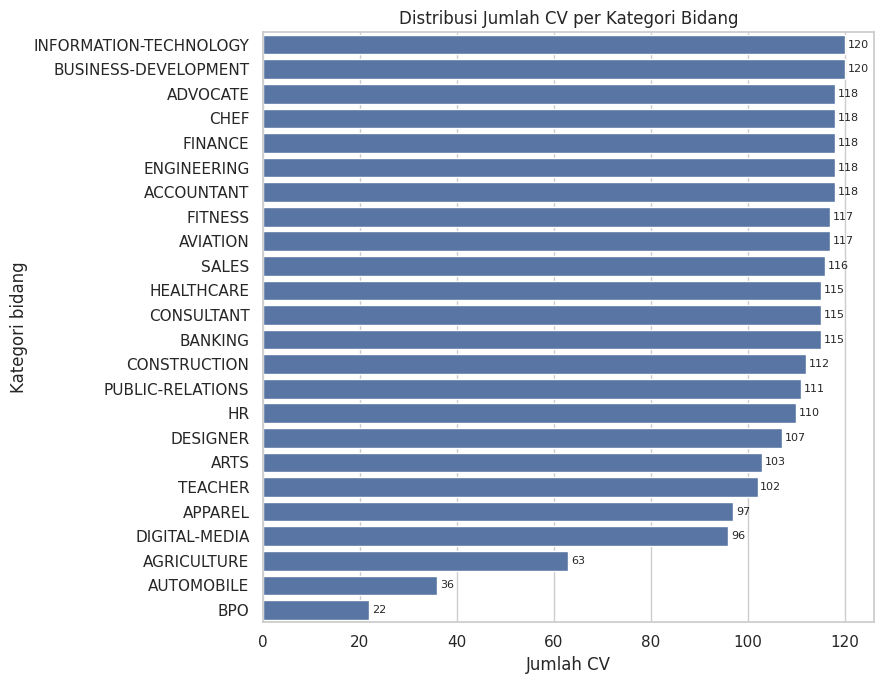

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
urut = df['Category'].value_counts().index
sns.countplot(data=df, y='Category', order=urut, ax=ax, color='#4C72B0')
for c in ax.containers:
    ax.bar_label(c, padding=2, fontsize=8)
ax.set_title('Distribusi Jumlah CV per Kategori Bidang')
ax.set_xlabel('Jumlah CV')
ax.set_ylabel('Kategori bidang')
plt.tight_layout()
plt.show()

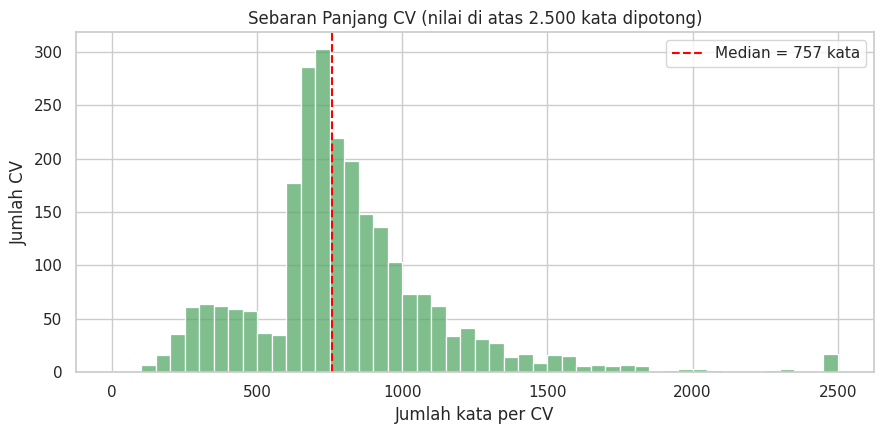

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df['n_kata'].clip(upper=2500), bins=50, ax=ax, color='#55A868')
med = df['n_kata'].median()
ax.axvline(med, color='red', linestyle='--', label=f'Median = {med:.0f} kata')
ax.set_title('Sebaran Panjang CV (nilai di atas 2.500 kata dipotong)')
ax.set_xlabel('Jumlah kata per CV')
ax.set_ylabel('Jumlah CV')
ax.legend()
plt.tight_layout()
plt.show()

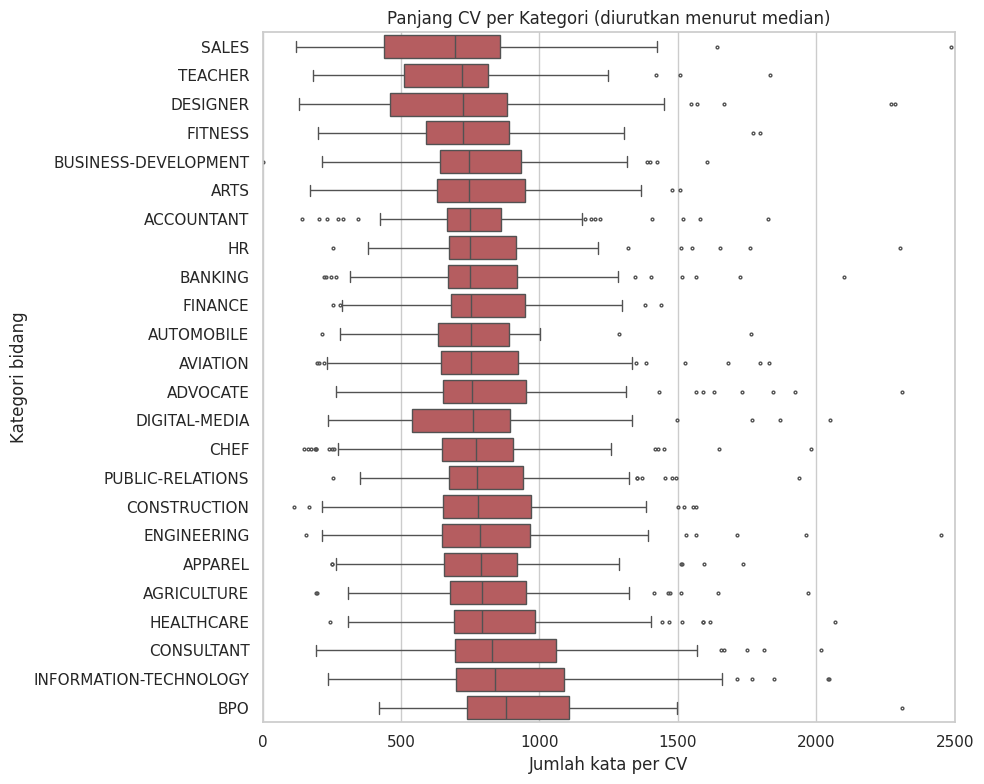

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
urut_median = df.groupby('Category')['n_kata'].median().sort_values().index
sns.boxplot(data=df, y='Category', x='n_kata', order=urut_median, ax=ax, color='#C44E52', fliersize=2)
ax.set_xlim(0, 2500)
ax.set_title('Panjang CV per Kategori (diurutkan menurut median)')
ax.set_xlabel('Jumlah kata per CV')
ax.set_ylabel('Kategori bidang')
plt.tight_layout()
plt.show()

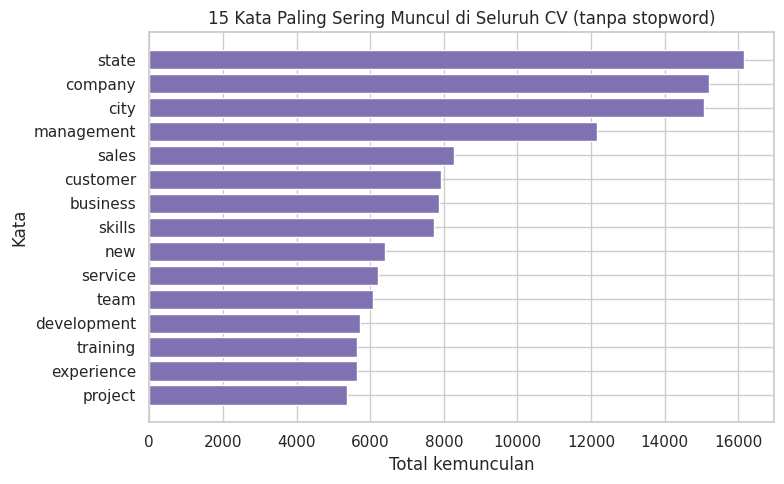

state          16159
company        15212
city           15077
management     12173
sales           8275
customer        7927
business        7866
skills          7729
new             6407
service         6223
team            6073
development     5731
training        5637
experience      5631
project         5362


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', max_features=15, token_pattern=r'(?u)\b[a-zA-Z]{3,}\b', lowercase=True)
cnt = cv.fit_transform(df['Resume_str'])
kata = pd.Series(np.asarray(cnt.sum(axis=0)).ravel(), index=cv.get_feature_names_out()).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(kata.index, kata.values, color='#8172B2')
ax.set_title('15 Kata Paling Sering Muncul di Seluruh CV (tanpa stopword)')
ax.set_xlabel('Total kemunculan')
ax.set_ylabel('Kata')
plt.tight_layout()
plt.show()
print(kata.sort_values(ascending=False).to_string())

### 2e. Insights
**1. Kelas tidak seimbang, dan tiga bidang sangat kecil.** Jumlah CV per bidang berkisar dari 120 (INFORMATION-TECHNOLOGY dan BUSINESS-DEVELOPMENT) sampai hanya 22 (BPO), rasio sekitar 5,5 : 1. Sebanyak 19 dari 24 bidang punya sedikitnya 100 CV, sedangkan AGRICULTURE (63), AUTOMOBILE (36), dan BPO (22) jauh lebih kecil. **Dampak bagi pemodelan:** split harus memakai `stratify` supaya bidang kecil tetap ada di data uji (BPO hanya akan punya sekitar 4–5 CV uji). Hasil per bidang kecil akan bervariasi besar, sehingga selain Recall@k dan MRR perlu dilaporkan **Macro Recall@1** agar kegagalan di bidang kecil tidak tertutup oleh bidang besar. Tebakan acak hanya mencapai sekitar 4,2% dan menebak kelas terbanyak terus-menerus sekitar 4,8%, jadi angka itulah batas bawah yang harus dilampaui.

**2. Teks CV penuh boilerplate yang bukan informasi bidang.** Tiga kata paling sering di seluruh korpus adalah `state` (16.159), `company` (15.212), dan `city` (15.077). Ketiganya berasal dari placeholder "Company Name" (ada di 100% CV) dan "City , State" (ada di 95,1% CV), bukan dari isi pekerjaan. Kata bermakna seperti `management`, `sales`, dan `customer` baru muncul sesudahnya, dan banyak di antaranya umum di banyak bidang. **Dampak:** placeholder ini harus dibuang saat pembersihan, dan pembobotan TF-IDF (IDF, `max_df`, stopword) penting agar kata yang muncul di hampir semua CV tidak mendominasi kemiripan. Kata umum seperti `management` juga menjelaskan mengapa pencocokan kata kunci sederhana berisiko memberi skor yang mirip ke banyak bidang.

**3. Ada masalah kualitas data kecil tetapi nyata.** Terdapat 2 pasang CV dengan teks sama persis tetapi ID berbeda (FINANCE dan AVIATION, labelnya sama), 1 CV kosong (hanya spasi, 0 kata, bidang BUSINESS-DEVELOPMENT), dan data pribadi yang masih tersisa di teks: email di 0,8% CV, URL di 4,0%, dan nomor telepon di 2,3%. Kolom `Resume_html` hanyalah versi HTML dari teks yang sama (himpunan katanya identik pada 200 CV sampel, dan 2 duplikat yang sama juga muncul di sana) sehingga tidak menambah informasi. **Dampak:** duplikat harus dibuang sebelum split supaya CV yang sama tidak masuk ke data latih dan data uji sekaligus (*leakage*), CV kosong dibuang, dan email, URL, serta telepon di-*mask* untuk menjaga privasi. `ID` dan `Resume_html` tidak dipakai sebagai fitur. Penulisan kategori sudah konsisten (24 nilai unik, tanpa variasi huruf atau spasi), jadi tidak perlu normalisasi label.

**4. Panjang CV hampir sama di semua bidang.** Median panjang CV adalah 757 kata (rentang antar-kuartil 651–933), dan median per bidang hanya berkisar dari 696 (SALES) sampai 878 (BPO). Ada 16 CV yang sangat panjang (lebih dari 2.500 kata) sebagai pencilan. **Dampak:** panjang CV hampir tidak membedakan bidang, jadi bukan fitur yang menjanjikan untuk klasifikasi. Pembeda utama ada pada **isi kata**, sehingga representasi teks (TF-IDF) yang dipakai sebagai fitur utama. Normalisasi panjang (vektor TF-IDF dinormalisasi L2, `sublinear_tf`) dibutuhkan agar CV panjang tidak otomatis mendapat skor kemiripan lebih besar.